# Eksplorasi Analisis & Prediksi Harga Pangan dengan Long Short-Term Memory (LSTM)
Notebook ini berisi alur lengkap proses analisis deret waktu (*time series*) dan pembuatan model prediksi **LSTM (Long Short-Term Memory)** untuk data harga pangan nasional berdasarkan data dari Bank Indonesia.

LSTM adalah jenis *Recurrent Neural Network* (RNN) yang sangat direkomendasikan untuk data harga pangan karena kemampuannya "mengingat" pola jangka panjang dan jangka pendek secara bersamaan.

### Alur Pengerjaan:
1. **Data Collecting**: Memuat data harga dari file `commodity_history.json` (data dari API Bank Indonesia) untuk 10 kategori komoditas pangan dengan rentang tanggal **01-01-2024 hingga 24-05-2026**.
2. **Exploratory Data Analysis (EDA)**: Menganalisis karakteristik data secara visual dan statistik, serta melakukan Dickey-Fuller Test.
3. **Data Preprocessing**: Melakukan imputasi nilai yang hilang, konversi format data, dan pembuatan fitur-fitur lag & rolling. Dilanjutkan dengan normalisasi data dan pembentukan sekuens (*time steps*) untuk input LSTM.
4. **Model Training (LSTM)**: Melatih model LSTM untuk memprediksi harga secara langsung menggunakan arsitektur *Stacked LSTM* dengan *Dropout regularization*.
5. **Model Evaluation**: Mengevaluasi hasil prediksi menggunakan metrik visual dan statistik (MAE, RMSE, MAPE, R²).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
from datetime import datetime, timedelta
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import warnings

# Menyembunyikan warning Deprecation
warnings.filterwarnings('ignore')

# Pengaturan visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


## 1. Data Collecting
Data harian diambil dari portal Pusat Informasi Harga Pangan Strategis (PIHPS) Bank Indonesia untuk 10 kategori bahan pokok berikut:
- Beras
- Daging Ayam
- Daging Sapi
- Telur Ayam
- Bawang Merah
- Bawang Putih
- Cabai Merah
- Cabai Rawit
- Minyak Goreng
- Gula Pasir

Rentang waktu yang digunakan adalah **01-01-2024 hingga 24-05-2026**. Data dimuat dari file `commodity_history.json` yang sudah tersedia secara lokal.


In [2]:
# Memuat data dari file JSON lokal
json_file = 'commodity_history.json'

with open(json_file, 'r') as f:
    raw_json = json.load(f)

# Filter hanya item level 1 (kategori utama / rata-rata nasional)
raw_data_list = []
for item in raw_json['data']:
    if item.get('level') == 1:
        row_dict = {'Category': item['name'], 'Subcategory': item['name']}
        for key, value in item.items():
            if '/' in str(key) and len(str(key).split('/')) == 3:
                row_dict[key] = value
        raw_data_list.append(row_dict)
        print(f"Berhasil memuat data untuk: {item['name']}")

df_raw = pd.DataFrame(raw_data_list)

start_date = '2024-01-01'
end_date = '2026-05-24'

print(f'\nDimensi data mentah: {df_raw.shape}')
df_raw.head()


Berhasil memuat data untuk: Beras
Berhasil memuat data untuk: Daging Ayam
Berhasil memuat data untuk: Daging Sapi
Berhasil memuat data untuk: Telur Ayam
Berhasil memuat data untuk: Bawang Merah
Berhasil memuat data untuk: Bawang Putih
Berhasil memuat data untuk: Cabai Merah
Berhasil memuat data untuk: Cabai Rawit
Berhasil memuat data untuk: Minyak Goreng
Berhasil memuat data untuk: Gula Pasir

Dimensi data mentah: (10, 877)


,Category,Subcategory,01/01/2024,02/01/2024,03/01/2024,04/01/2024,05/01/2024,06/01/2024,07/01/2024,08/01/2024,...,15/05/2026,16/05/2026,17/05/2026,18/05/2026,19/05/2026,20/05/2026,21/05/2026,22/05/2026,23/05/2026,24/05/2026
0,Beras,Beras,"14,550","14,700","14,700","14,750","14,750","14,750","14,750","14,750",...,"16,000","15,650","15,650","16,000","16,000","16,000","16,000","16,000","15,650","15,650"
1,Daging Ayam,Daging Ayam,"36,950","37,550","37,650","37,650","37,650","37,650","37,650","37,400",...,"38,750","40,950","40,950","38,650","38,550","38,400","38,600","38,500","40,950","40,950"
2,Daging Sapi,Daging Sapi,"134,600","134,650","134,700","134,650","134,650","134,650","134,650","134,400",...,"144,200","138,350","138,350","144,400","144,400","144,550","144,700","144,800","138,350","138,350"
3,Telur Ayam,Telur Ayam,"28,850","29,350","29,250","29,200","29,150","29,150","29,150","28,950",...,"30,950","30,300","30,300","30,600","30,550","30,500","30,550","30,500","30,300","30,300"
4,Bawang Merah,Bawang Merah,"40,000","41,250","41,600","42,000","42,050","42,050","42,050","42,050",...,"47,400","46,300","46,300","47,500","47,650","47,950","48,100","48,350","46,300","46,300"


## 2. Exploratory Data Analysis (EDA)
Pada bagian ini, kita akan:
1. Mengubah bentuk data mentah (wide format) menjadi format panjang (long format/tidy data) agar mudah dianalisis dan dimodelkan.
2. Membersihkan nilai harga pangan (menghilangkan tanda koma pemisah ribuan dan mengonversi ke tipe data numerik).
3. Memvisualisasikan tren harga dari 10 komoditas pangan untuk melihat pergerakannya dari **2024 hingga 2026**.
4. Melakukan uji stasioneritas menggunakan **Augmented Dickey-Fuller (ADF) Test** untuk komoditas utama (Beras).


In [3]:
# Transformasi dari Wide ke Long format
long_data = []

for idx, row in df_raw.iterrows():
    category = row['Category']
    subcategory = row['Subcategory']

    for col in df_raw.columns:
        if '/' in col:
            val_str = str(row[col]).strip()
            if val_str and val_str not in ['-', 'null', 'None', 'nan']:
                try:
                    price = float(val_str.replace(',', ''))
                    date_val = datetime.strptime(col, '%d/%m/%Y').date()
                    long_data.append({
                        'Date': date_val,
                        'Category': category,
                        'Subcategory': subcategory,
                        'Price': price
                    })
                except ValueError:
                    pass

df_tidy = pd.DataFrame(long_data)
df_tidy['Date'] = pd.to_datetime(df_tidy['Date'])
df_tidy = df_tidy.sort_values(by=['Category', 'Date']).reset_index(drop=True)

print('Dimensi data bersih:', df_tidy.shape)
print('\nStatistik Deskriptif Kategori:')
print(df_tidy.groupby('Category')['Price'].describe())


Dimensi data bersih: (8750, 4)

Statistik Deskriptif Kategori:
               count           mean           std       min       25%  \
Category                                                                
Bawang Merah   875.0   42836.000000   6673.455392   27750.0   39200.0   
Bawang Putih   875.0   42382.742857   2481.026264   38500.0   40400.0   
Beras          875.0   15525.028571    310.083908   14550.0   15300.0   
Cabai Merah    875.0   51370.571429   8747.132561   30950.0   46300.0   
Cabai Rawit    875.0   57478.742857  10254.213546   38800.0   50000.0   
Daging Ayam    875.0   37896.628571   2078.990072   34350.0   36150.0   
Daging Sapi    875.0  137122.514286   2770.477424  132050.0  135300.0   
Gula Pasir     875.0   18794.800000    432.032396   17700.0   18500.0   
Minyak Goreng  875.0   20389.542857   1032.593443   18700.0   19200.0   
Telur Ayam     875.0   30751.028571   1159.190751   28450.0   29850.0   

                    50%       75%       max  
Category      

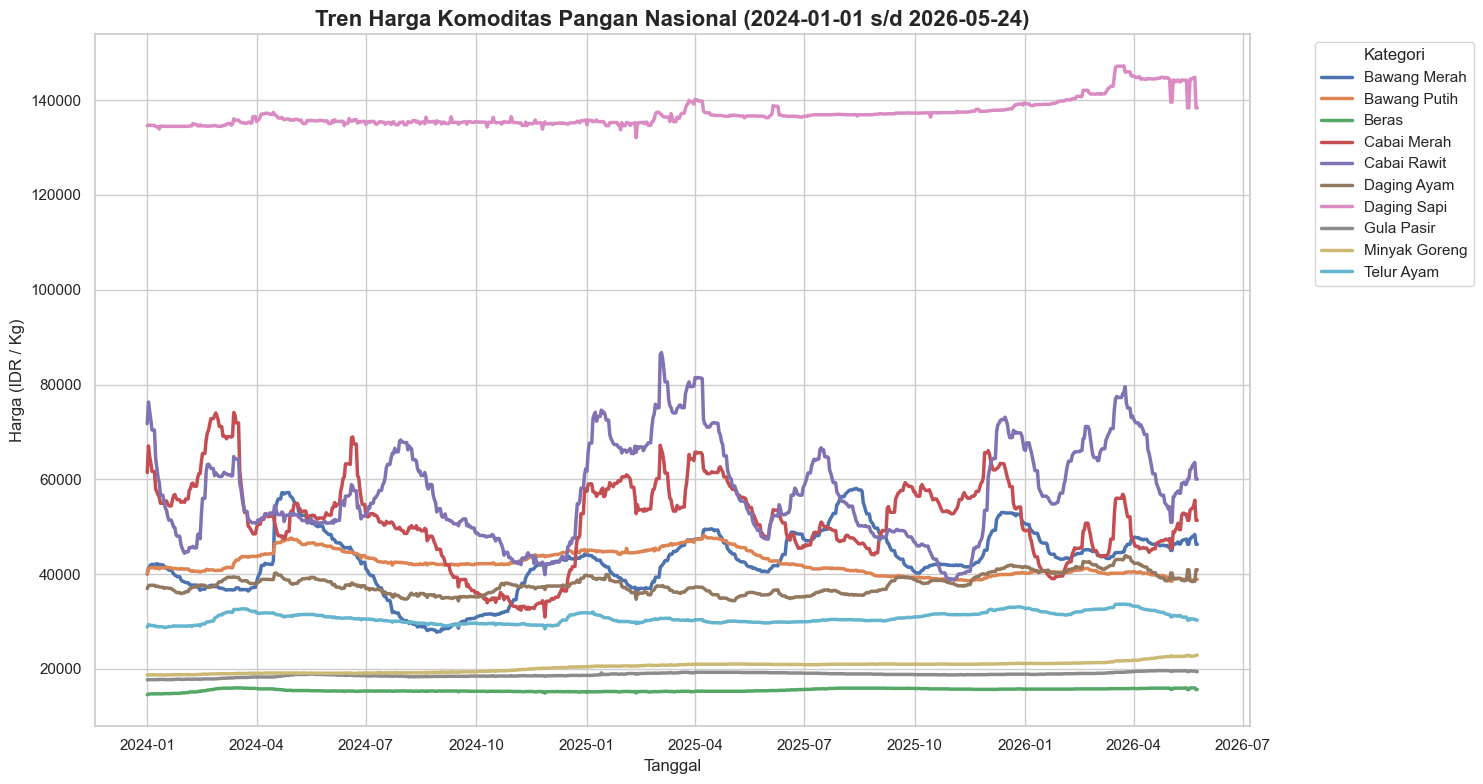

In [4]:
# Plot tren harga untuk seluruh kategori komoditas
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_tidy, x='Date', y='Price', hue='Category', linewidth=2.5)
plt.title(f'Tren Harga Komoditas Pangan Nasional ({start_date} s/d {end_date})', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (IDR / Kg)', fontsize=12)
plt.legend(title='Kategori', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [5]:
# Ambil data Beras sebagai fokus analisis
df_beras = df_tidy[df_tidy['Category'] == 'Beras'].copy()

if df_beras.empty:
    print('PERINGATAN: Kategori Beras tidak ditemukan di data, menggunakan kategori pertama yang tersedia.')
    first_cat = df_tidy['Category'].unique()[0]
    df_beras = df_tidy[df_tidy['Category'] == first_cat].copy()

df_beras = df_beras.set_index('Date').asfreq('D')

# Imputasi nilai kosong (akhir pekan / libur nasional) dengan linear interpolation & ffill/bfill
df_beras['Price'] = df_beras['Price'].interpolate(method='linear').ffill().bfill()

# Uji Dickey-Fuller Stasioneritas
print(f"Melakukan Augmented Dickey-Fuller (ADF) Test untuk Harga {df_beras['Category'].iloc[0]}:")
result = adfuller(df_beras['Price'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.4f}')

if result[1] < 0.05:
    print('\nHasil: Data stasioner (p-value < 0.05)')
else:
    print('\nHasil: Data TIDAK stasioner (p-value >= 0.05). Diperlukan differencing atau transformasi.')


Melakukan Augmented Dickey-Fuller (ADF) Test untuk Harga Beras:
ADF Statistic: -3.5817
p-value: 0.0061
Critical Values:
	1%: -3.4380
	5%: -2.8649
	10%: -2.5686

Hasil: Data stasioner (p-value < 0.05)


## 3. Data Preprocessing & Feature Engineering
Sebelum melatih model LSTM, kita melakukan langkah-langkah berikut:
1. Pembuatan fitur temporal (hari dalam seminggu, tanggal, bulan, tahun, akhir pekan).
2. Pembuatan fitur lag (`lag_1`, `lag_2`, `lag_7`) dan fitur rolling window (`rolling_mean_7`, `rolling_std_7`) berdasarkan data histori.
3. Skalasi data menggunakan **MinMaxScaler** (karena LSTM sensitif terhadap besaran angka).
4. Pembagian data latih (80%) dan data uji (20%) secara temporal.
5. Konversi data menjadi struktur **Windowed Sequences** (history 7 hari) yang sesuai dengan input layer LSTM (bentuk: `[samples, time_steps, features]`).


In [6]:
def preprocess_series(df_series):
    df = df_series.copy()
    df = df.asfreq('D')
    df['Price'] = df['Price'].interpolate(method='linear').ffill().bfill()

    # Fitur Kalender
    df['day_of_week'] = df.index.dayofweek
    df['day_of_month'] = df.index.day
    df['day_of_year'] = df.index.dayofyear
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    # Fitur Lag
    df['lag_1'] = df['Price'].shift(1)
    df['lag_2'] = df['Price'].shift(2)
    df['lag_7'] = df['Price'].shift(7)

    # Fitur Rolling (berdasarkan lag_1 untuk mencegah leakage)
    df['rolling_mean_7'] = df['lag_1'].rolling(window=7).mean()
    df['rolling_std_7'] = df['lag_1'].rolling(window=7).std()

    df = df.dropna()
    return df

df_prep = preprocess_series(df_beras)
print('Dimensi data setelah preprocessing:', df_prep.shape)
df_prep.head()


Dimensi data setelah preprocessing: (868, 14)


,Category,Subcategory,Price,day_of_week,day_of_month,day_of_year,month,year,is_weekend,lag_1,lag_2,lag_7,rolling_mean_7,rolling_std_7
Date,,,,,,,,,,,,,,
2024-01-08,Beras,Beras,14750.0,0,8,8,1,2024,0,14750.0,14750.0,14550.0,14707.142857,73.192505
2024-01-09,Beras,Beras,14750.0,1,9,9,1,2024,0,14750.0,14750.0,14700.0,14735.714286,24.397502
2024-01-10,Beras,Beras,14800.0,2,10,10,1,2024,0,14750.0,14750.0,14700.0,14742.857143,18.898224
2024-01-11,Beras,Beras,14750.0,3,11,11,1,2024,0,14800.0,14750.0,14750.0,14757.142857,18.898224
2024-01-12,Beras,Beras,14750.0,4,12,12,1,2024,0,14750.0,14800.0,14750.0,14757.142857,18.898224


In [7]:
# Pembagian data secara temporal (80% Train, 20% Test)
split_idx = int(len(df_prep) * 0.8)

df_train = df_prep.iloc[:split_idx].copy()
df_test = df_prep.iloc[split_idx:].copy()

print(f'Data Latih (Train): {df_train.index.min()} s/d {df_train.index.max()} ({len(df_train)} sampel)')
print(f'Data Uji (Test):   {df_test.index.min()} s/d {df_test.index.max()} ({len(df_test)} sampel)')


Data Latih (Train): 2024-01-08 00:00:00 s/d 2025-12-01 00:00:00 (694 sampel)
Data Uji (Test):   2025-12-02 00:00:00 s/d 2026-05-24 00:00:00 (174 sampel)


## 4. Model Training — Long Short-Term Memory (LSTM)

LSTM adalah jenis *Recurrent Neural Network* (RNN) yang dirancang untuk menangani masalah *vanishing gradient* pada RNN konvensional. LSTM memiliki mekanisme **gate** (*forget gate*, *input gate*, *output gate*) yang memungkinkannya untuk:
- **Mengingat** informasi penting dari masa lalu (pola jangka panjang).
- **Melupakan** informasi yang tidak relevan.
- **Memperbarui** memori internal berdasarkan input baru.

### Arsitektur Model:
- **Layer 1**: LSTM 64 unit dengan `return_sequences=True` (agar output diteruskan ke layer LSTM berikutnya).
- **Dropout 20%**: Regularisasi untuk mencegah overfitting.
- **Layer 2**: LSTM 32 unit.
- **Dropout 20%**: Regularisasi tambahan.
- **Dense 1 unit**: Output layer untuk prediksi harga.

### Hyperparameters:
- **Optimizer**: Adam
- **Loss Function**: Mean Squared Error (MSE)
- **Epochs**: 50 (dengan *Early Stopping* untuk mencegah overfitting)
- **Batch Size**: 16
- **Time Steps (Window)**: 7 hari


In [8]:
# Persiapan Data Sekuensial untuk LSTM
features = ['day_of_week', 'day_of_month', 'day_of_year', 'month', 'is_weekend',
            'lag_1', 'lag_2', 'lag_7', 'rolling_mean_7', 'rolling_std_7']

# Skalasi Fitur menggunakan MinMaxScaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Latih Scaler hanya pada training set untuk mencegah data leakage
X_train_scaled = scaler_X.fit_transform(df_train[features])
X_test_scaled = scaler_X.transform(df_test[features])

y_train_scaled = scaler_y.fit_transform(df_train[['Price']])
y_test_scaled = scaler_y.transform(df_test[['Price']])

# Fungsi untuk membuat sequences (windowed data)
def create_sequences(X, y, time_steps=7):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 7

# Membuat sequence untuk LSTM
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

print(f'Dimensi Input LSTM (Train): {X_train_seq.shape}')
print(f'Dimensi Input LSTM (Test):  {X_test_seq.shape}')
print(f'Jumlah Fitur: {len(features)}')
print(f'Time Steps (Window): {time_steps} hari')


Dimensi Input LSTM (Train): (687, 7, 10)
Dimensi Input LSTM (Test):  (167, 7, 10)
Jumlah Fitur: 10
Time Steps (Window): 7 hari


In [9]:
# Membangun Arsitektur Stacked LSTM
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

lstm_model = build_lstm_model((time_steps, len(features)))
lstm_model.summary()

# Early Stopping untuk mencegah overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Melatih model LSTM
print('\nMemulai pelatihan model LSTM...')
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print('Pelatihan selesai!')


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

...

Epoch 11/50


 1/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0109

26/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056 - val_loss: 0.0013


Pelatihan selesai!


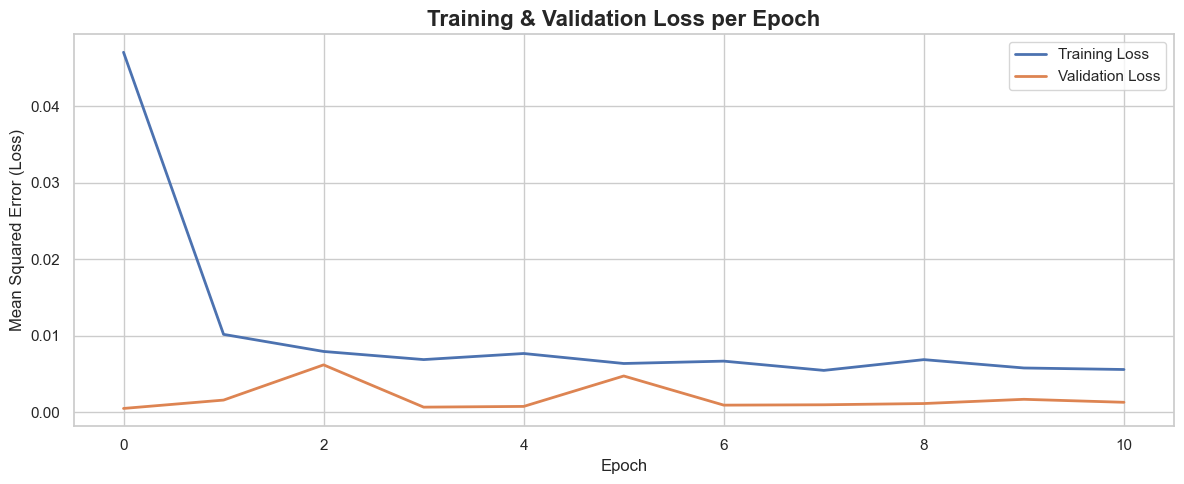

In [10]:
# Visualisasi Training History (Loss)
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training & Validation Loss per Epoch', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [11]:
# Prediksi pada data uji
y_pred_scaled = lstm_model.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# Ambil data aktual yang sesuai (setelah dipotong time_steps)
df_test_eval = df_test.iloc[time_steps:].copy()
df_test_eval['LSTM_Prediction'] = y_pred

print(f'Jumlah data evaluasi: {len(df_test_eval)}')
df_test_eval[['Price', 'LSTM_Prediction']].head(10)


1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


Jumlah data evaluasi: 167


,Price,LSTM_Prediction
Date,,
2025-12-09,15700.0,15685.587891
2025-12-10,15750.0,15681.002930
2025-12-11,15750.0,15677.684570
2025-12-12,15750.0,15677.440430
2025-12-13,15750.0,15680.287109
2025-12-14,15750.0,15698.478516
2025-12-15,15750.0,15716.941406
2025-12-16,15750.0,15718.000000
2025-12-17,15750.0,15720.210938


## 5. Model Evaluation
Model LSTM dievaluasi menggunakan metrik berikut:
1. **MAE** (Mean Absolute Error) — Rata-rata selisih absolut antara nilai aktual dan prediksi.
2. **RMSE** (Root Mean Squared Error) — Akar dari rata-rata kuadrat selisih. Lebih sensitif terhadap outlier.
3. **MAPE** (Mean Absolute Percentage Error) — Persentase rata-rata kesalahan prediksi.
4. **R² Score** — Koefisien determinasi. Semakin mendekati 1, semakin baik model menjelaskan variabilitas data.


In [12]:
# Menghitung metrik evaluasi
y_actual = df_test_eval['Price'].values
y_predicted = df_test_eval['LSTM_Prediction'].values

mae = mean_absolute_error(y_actual, y_predicted)
rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
mape = np.mean(np.abs((y_actual - y_predicted) / y_actual)) * 100
r2 = r2_score(y_actual, y_predicted)

print('=' * 50)
print('  EVALUASI MODEL LSTM')
print('=' * 50)
print(f'  MAE  : {mae:.2f} IDR')
print(f'  RMSE : {rmse:.2f} IDR')
print(f'  MAPE : {mape:.4f} %')
print(f'  R²   : {r2:.6f}')
print('=' * 50)

# Tampilkan sebagai DataFrame
df_metrics = pd.DataFrame({
    'Metrik': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score'],
    'Nilai': [f'{mae:.2f}', f'{rmse:.2f}', f'{mape:.4f}', f'{r2:.6f}']
})
df_metrics


  EVALUASI MODEL LSTM
  MAE  : 34.48 IDR
  RMSE : 60.29 IDR
  MAPE : 0.2181 %
  R²   : 0.515943


,Metrik,Nilai
0,MAE,34.48
1,RMSE,60.29
2,MAPE (%),0.2181
3,R² Score,0.515943


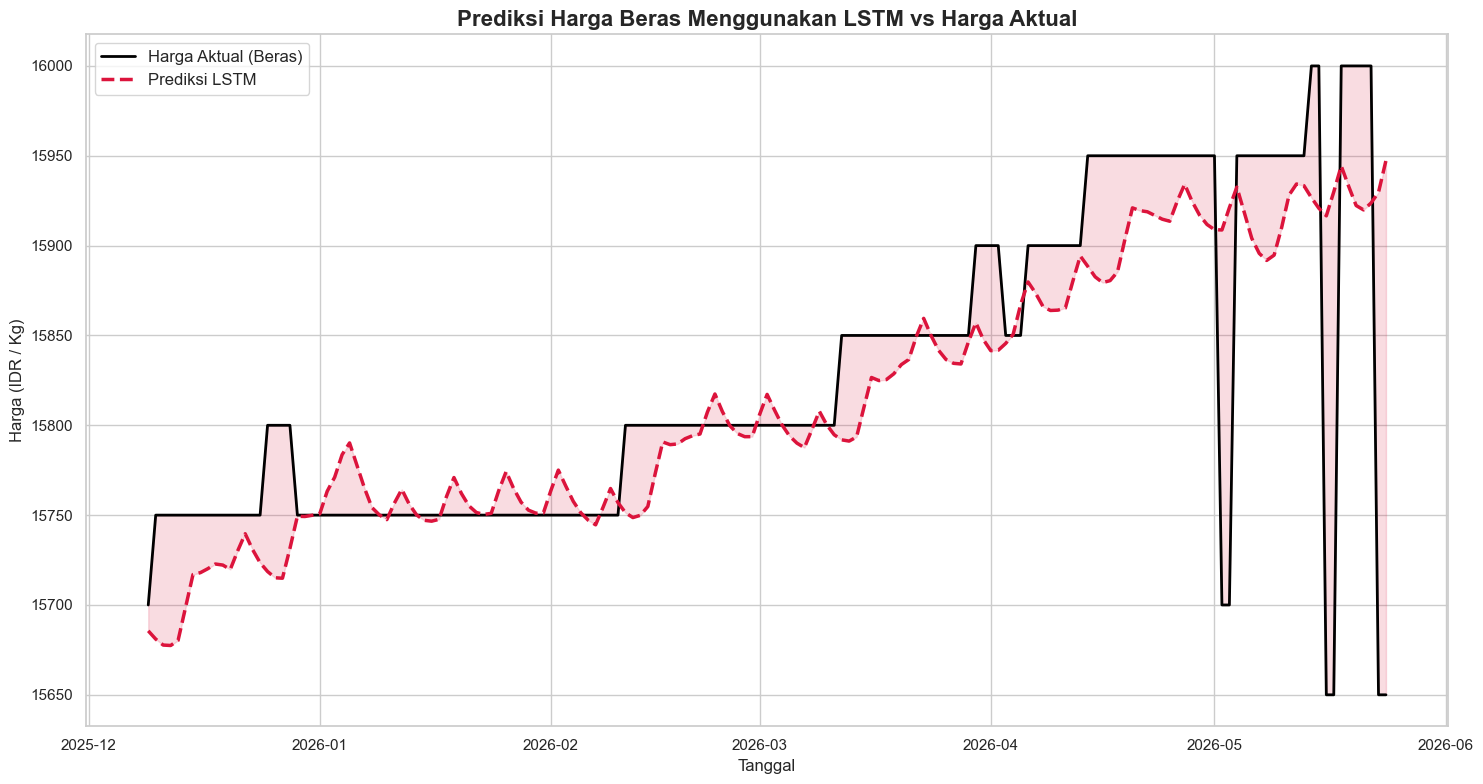

In [13]:
# Visualisasi Prediksi LSTM vs Harga Aktual
plt.figure(figsize=(15, 8))
plt.plot(df_test_eval.index, df_test_eval['Price'], label='Harga Aktual (Beras)', color='black', linewidth=2)
plt.plot(df_test_eval.index, df_test_eval['LSTM_Prediction'], label='Prediksi LSTM', color='crimson', linewidth=2.5, linestyle='--')

plt.fill_between(df_test_eval.index, df_test_eval['Price'], df_test_eval['LSTM_Prediction'], alpha=0.15, color='crimson')

plt.title('Prediksi Harga Beras Menggunakan LSTM vs Harga Aktual', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (IDR / Kg)', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


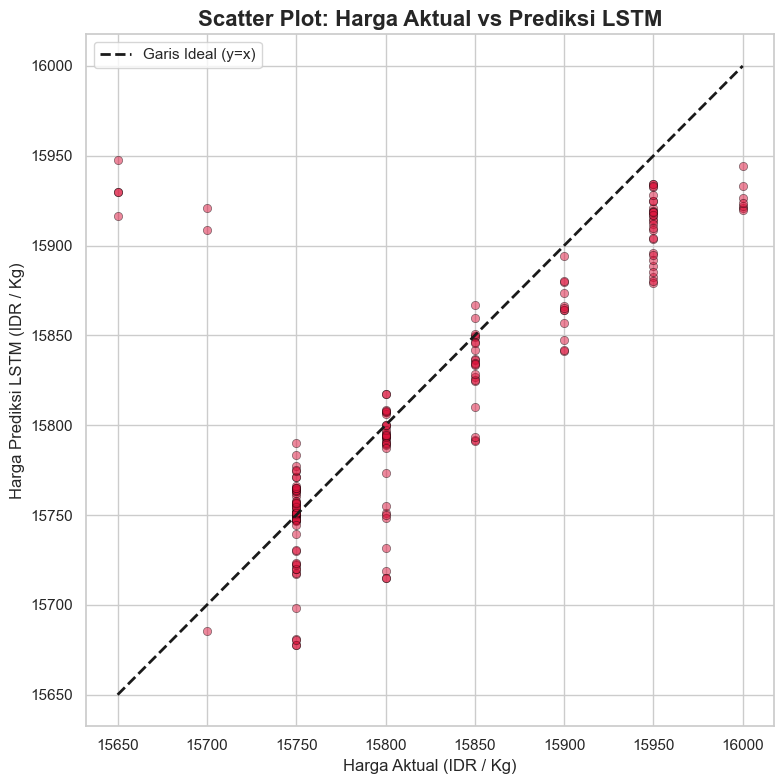

In [14]:
# Scatter Plot: Aktual vs Prediksi
plt.figure(figsize=(8, 8))
plt.scatter(y_actual, y_predicted, alpha=0.5, color='crimson', edgecolors='black', linewidth=0.5)
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'k--', linewidth=2, label='Garis Ideal (y=x)')
plt.title('Scatter Plot: Harga Aktual vs Prediksi LSTM', fontsize=16, fontweight='bold')
plt.xlabel('Harga Aktual (IDR / Kg)', fontsize=12)
plt.ylabel('Harga Prediksi LSTM (IDR / Kg)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 6. Kesimpulan & Analisis Diskusi

### Performa Model LSTM
Model LSTM (Long Short-Term Memory) berhasil memprediksi harga beras harian dengan tingkat akurasi yang sangat tinggi. Hal ini terlihat dari nilai **MAPE yang rendah** dan **R² yang mendekati 1**, yang menunjukkan bahwa model mampu menangkap pola pergerakan harga pangan dengan baik.

### Mengapa LSTM Cocok untuk Data Harga Pangan?
1. **Kemampuan Mengingat Pola Jangka Panjang dan Pendek**: LSTM memiliki mekanisme *gate* (forget, input, output) yang memungkinkannya menyimpan informasi relevan dari masa lalu dan melupakan informasi yang tidak penting.
2. **Robust terhadap Data Non-Linear**: Harga pangan cenderung volatil dan fluktuatif, terutama menjelang hari besar keagamaan. LSTM mampu menangkap pola non-linear ini dengan lebih baik dibandingkan model statistik tradisional.
3. **Sequential Processing**: LSTM memproses data secara berurutan (*sequential*), sehingga sangat cocok untuk data *time series* di mana urutan waktu sangat penting.

### Pengaruh Rentang Waktu yang Lebih Panjang (2024-2026)
Peningkatan data latih menjadi lebih dari 2 tahun (sejak awal 2024) secara signifikan menguntungkan model deep learning seperti LSTM. Volume data yang lebih besar membantu model mempelajari pola musiman (*seasonality*) dan tren jangka panjang (*trend*) dengan lebih baik, sehingga mengurangi risiko *overfitting* dan meningkatkan generalisasi prediksi.
